In [1]:
import torch
import cv2

In [4]:
def calcM(src_pts, dst_pts):
    M = cv2.getPerspectiveTransform(src_pts.numpy(), dst_pts.numpy())
    return torch.tensor(M, dtype=torch.float32)


def Mwarp(M, image, newSize):
    warppedImg = cv2.warpPerspective(image.numpy(), M, newSize)
    return warppedImg


def warpPts(src_pts, M):
    print(src_pts.shape, M.shape)
    tmp_pts = torch.cat([src_pts, torch.ones(src_pts.shape[0], 1)], dim=1)
    print(tmp_pts.shape)
    dst_pts = (M @ tmp_pts.T).T
    print(dst_pts.shape)
    dst_pts_norm = dst_pts / dst_pts[:, 2].unsqueeze(1)
    print(dst_pts_norm.shape)
    return dst_pts_norm[:, :2]

In [6]:
src_pts = torch.tensor([
    [100, 100],
    [500, 100],
    [500, 500],
    [100, 500]
], dtype=torch.float32)

dst_pts = torch.tensor([
    [0,0],
    [256,0],
    [256,256],
    [0,256]
], dtype=torch.float32)

M = calcM(src_pts, dst_pts)
warpPts(dst_pts, M.inverse())

torch.Size([4, 2]) torch.Size([3, 3])
torch.Size([4, 3])
torch.Size([4, 3])
torch.Size([4, 3])


tensor([[100., 100.],
        [500., 100.],
        [500., 500.],
        [100., 500.]])

# Test

In [1]:
import ChessLens
from OcclusionDetection import OcclusionDetectionCNN

from Dataset.DataSetLoaders import ChessDataset

import torch

In [2]:
ds = ChessDataset.ChessDataset(
    config={
        "img_size": (640, 640)
    }
)

img, _ = ds[5]

In [3]:
img = ChessLens.ChessLensImage(img, "cnn")
img.detect_board()

(tensor([[149.,  89.],
         [476.,  86.],
         [616., 503.],
         [ 33., 517.]]),
 np.float64(0.901025936235229))

In [4]:
occl = OcclusionDetectionCNN.OcclusionDetectorCNN()

occl.set_img(torch.tensor(img.warp()[0]).permute(2,1,0).unsqueeze(0).float() / 255)

In [7]:
occl.is_occluded()

tensor([[1.0000e+00, 8.4481e-11]])

# Dataset Test

In [1]:
from Dataset.DataSetLoaders import ChessDataset
from Utils import ChessUtils
from matplotlib import pyplot as plt

In [4]:
ds = ChessDataset.ChessDataset(
    "/mnt/C/CNN_Dataset/Chess_Set_Models/test",
    config={
        "img_size":(640,640)
    },
    force_build_pkl=True
)

len(ds)

9

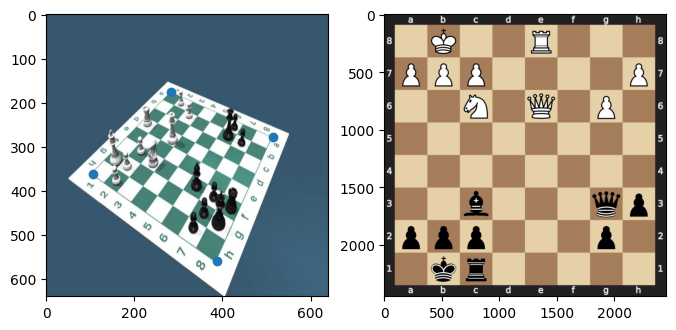

In [6]:
img, y = ds[1]

plt.figure(figsize=(8,12))
plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0));
plt.scatter(y["corners"][:,0], y["corners"][:,1]);

plt.subplot(1,2,2)
fen = ChessUtils.ChessTensorUtils.tensorToFEN_MAX(y["board_tensor"].unsqueeze(0))
ChessUtils.fen_to_png(fen, ".", "out_fen.png")
board = plt.imread("out_fen.png")
plt.imshow(board);